#Importing libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
df = pd.read_csv('cleaned_retail_day3.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  int64  
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
 8   Sales        392692 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 27.0+ MB


#Transaction Count

In [5]:
df['Country'].value_counts()

,count
Country,
United Kingdom,349203
Germany,9025
France,8326
EIRE,7226
Spain,2479
Netherlands,2359
Belgium,2031
Switzerland,1841
Portugal,1453


#Unique Customers

In [6]:
df['CustomerID'].nunique()

4338

#Unique Orders

In [7]:
df['InvoiceNo'].nunique()

18532

#Most Customers

In [8]:
df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)

,CustomerID
Country,
United Kingdom,3920
Germany,94
France,87
Spain,30
Belgium,25
Switzerland,21
Portugal,19
Italy,14
Finland,12


In [9]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Sales'],
      dtype='object')

In [10]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [11]:
df[['Quantity','UnitPrice','Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


# Exploratory Data Analysis (EDA)

Dataset: cleaned_retail_day3.csv

Objectives:
- Top 10 Countries by Transaction Count
- Top 10 Products by Quantity Sold
- Top 10 Products by Revenue
- Top 10 Countries by Revenue

In [12]:
top_countries = ( df.groupby('Country')['InvoiceNo'].count().sort_values(ascending=False).head(10)
)
top_countries

,InvoiceNo
Country,
United Kingdom,349203
Germany,9025
France,8326
EIRE,7226
Spain,2479
Netherlands,2359
Belgium,2031
Switzerland,1841
Portugal,1453


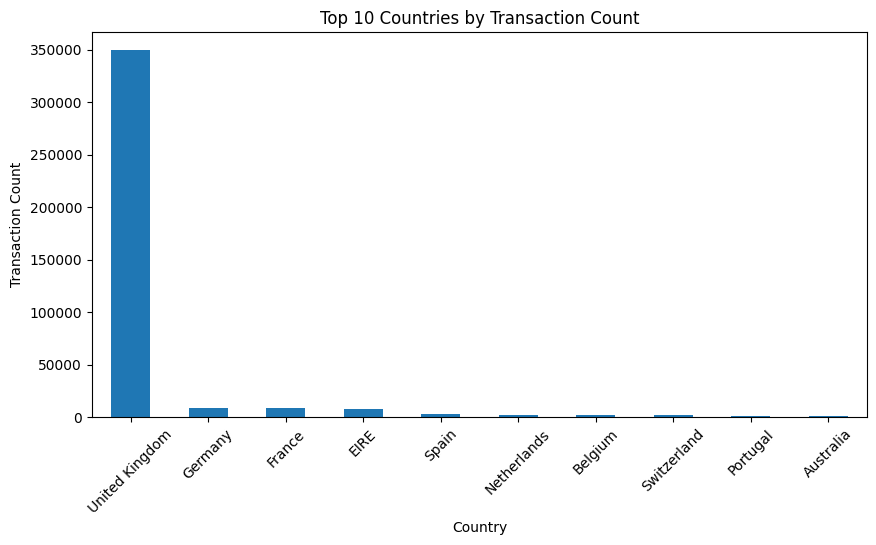

In [13]:
plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Transaction Count')
plt.xlabel('Country')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.show()

### Observation

The countries shown below have the highest number of transactions.

In [14]:
top_products_qty = (df.groupby('Description')['Quantity'].sum().sort_values(ascending=False) .head(10))
top_products_qty

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


#Top 10 Products by Quantity Sold

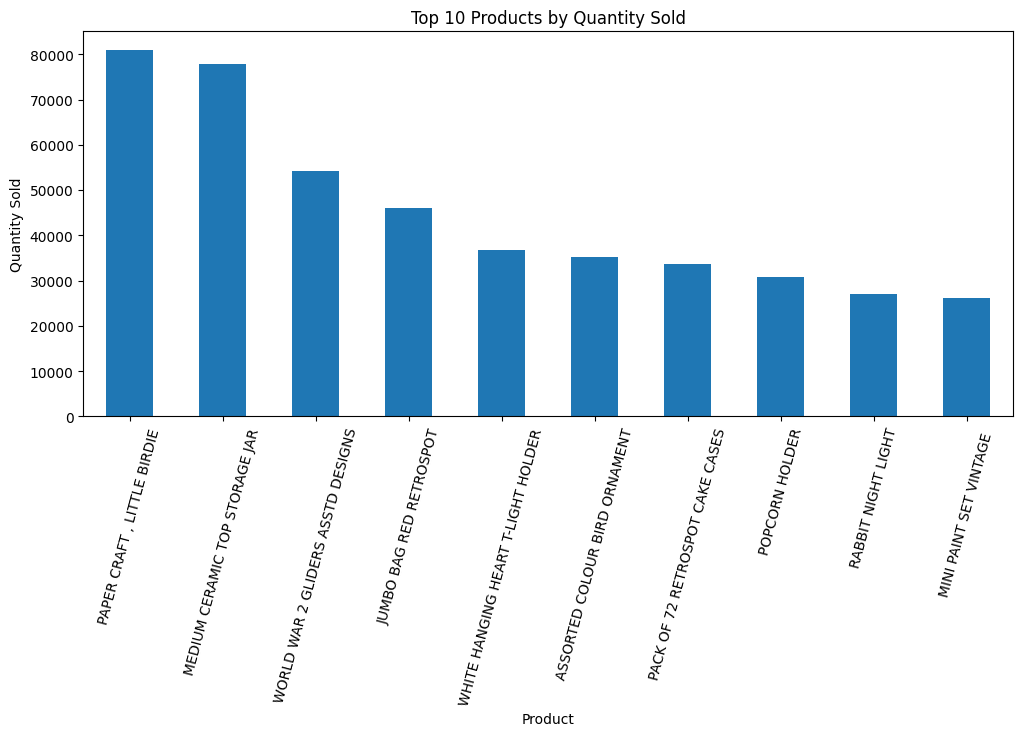

In [15]:
plt.figure(figsize=(12,5))
top_products_qty.plot(kind='bar')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=75)
plt.show()

#Top 10 Products by Quantity Sold

In [16]:
top_products_rev = (df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10))
top_products_rev

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


#Top 10 Countries by Revenue

In [17]:
top_country_rev = ( df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
)

top_country_rev

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


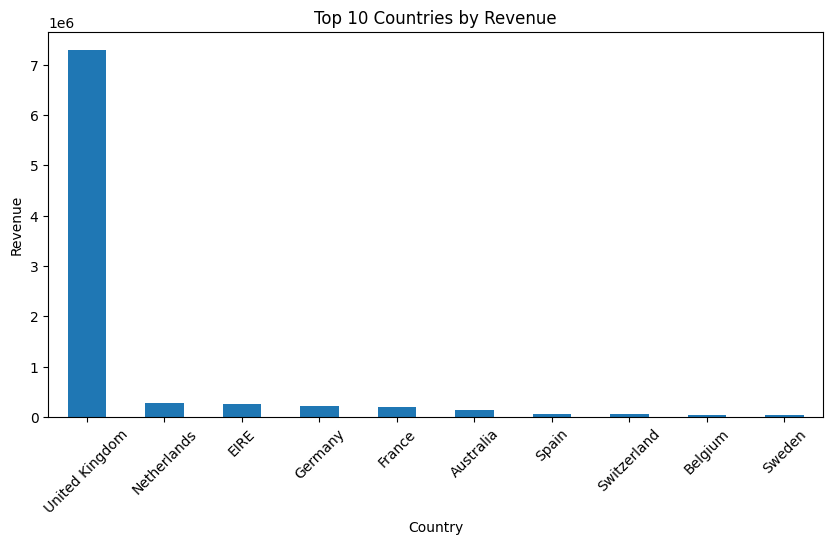

In [18]:
plt.figure(figsize=(10,5))
top_country_rev.plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

# Business Insights

1. The highest transaction volume comes from a small number of countries, indicating key target markets.

2. The top-selling products account for a significant portion of total quantity sold.

3. Products generating the highest revenue are not always the products sold in the highest quantities.

4. Revenue is concentrated among a few countries, suggesting strong geographic demand patterns.

5. Popular products should be prioritized in inventory planning to avoid stock shortages.

# Country with Highest Transactions

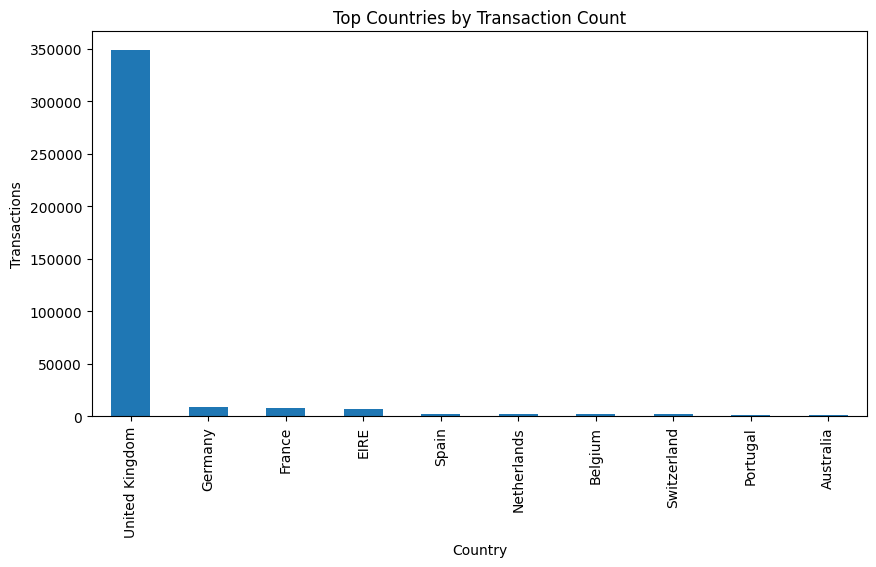

In [19]:
country_transactions = df.groupby('Country')['InvoiceNo'].count().sort_values(ascending=False)
plt.figure(figsize=(10,5))
country_transactions.head(10).plot(kind='bar')
plt.title('Top Countries by Transaction Count')
plt.xlabel('Country')
plt.ylabel('Transactions')
plt.show()

### Observation
- The country with the highest transaction count is United kingdom.
- This indicates strong customer activity from this region.
- Other countries contribute significantly less compared to the leading country.

#Country with Highest Revenue

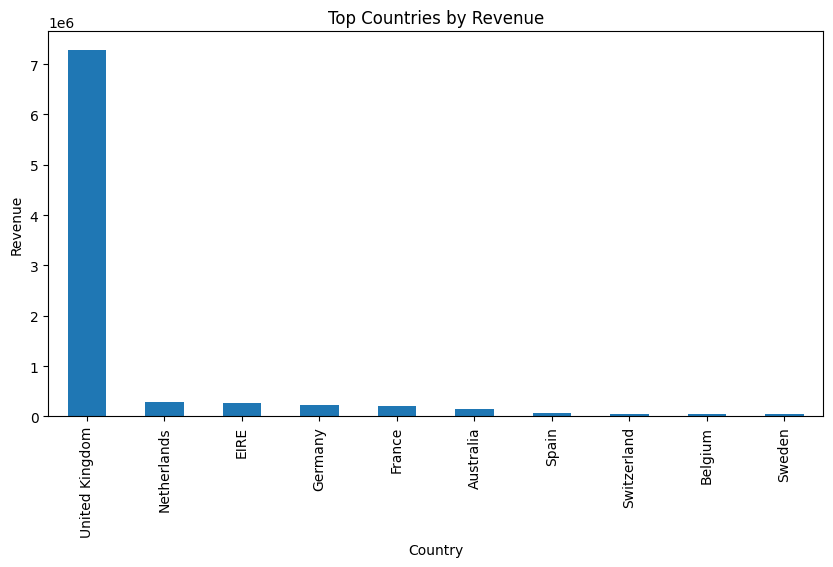

In [20]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
country_revenue.head(10).plot(kind='bar')
plt.title('Top Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.show()

### Observation
- United kingdom generates the highest revenue.
- High revenue may be driven by both transaction volume and order value.
- The company should focus on retaining customers from this market.

#Most Popular Products

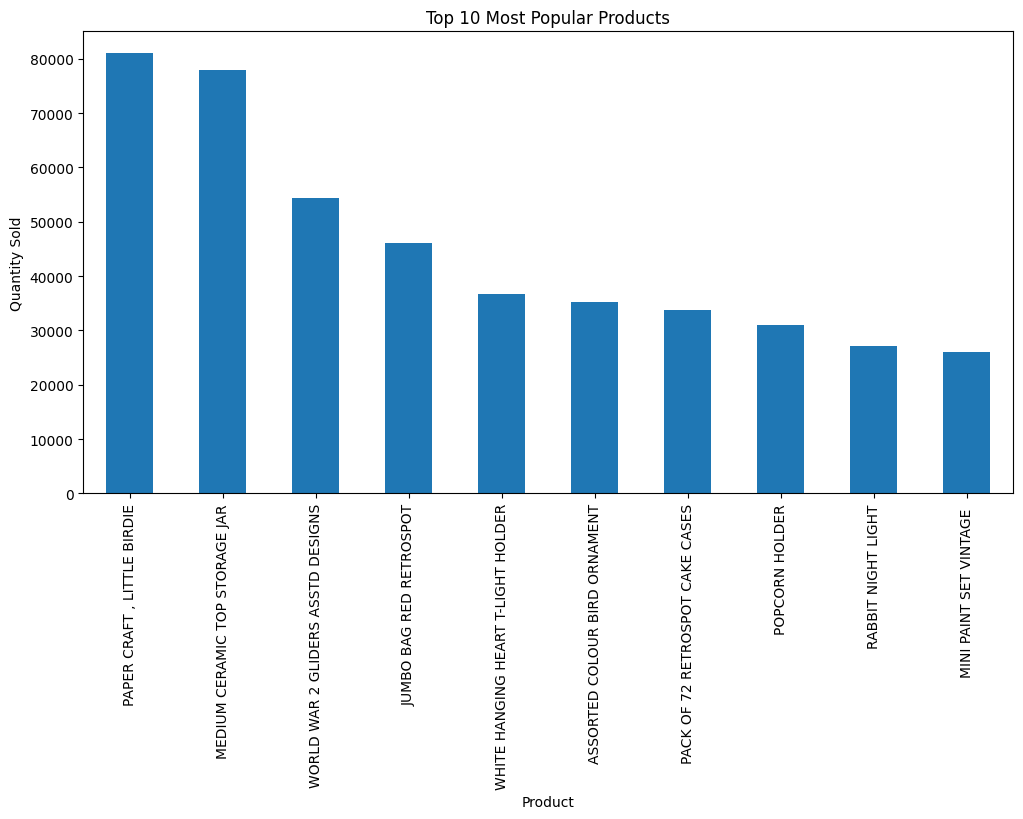

In [21]:
popular_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
popular_products.head(10).plot(kind='bar')
plt.title('Top 10 Most Popular Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.show()

### Observation
- The most popular product is PAPER CRAFT.LITTLE BIRDIE.
- These products have the highest demand among customers.
- Inventory planning should prioritize these products.

#Products Generating Highest Revenue

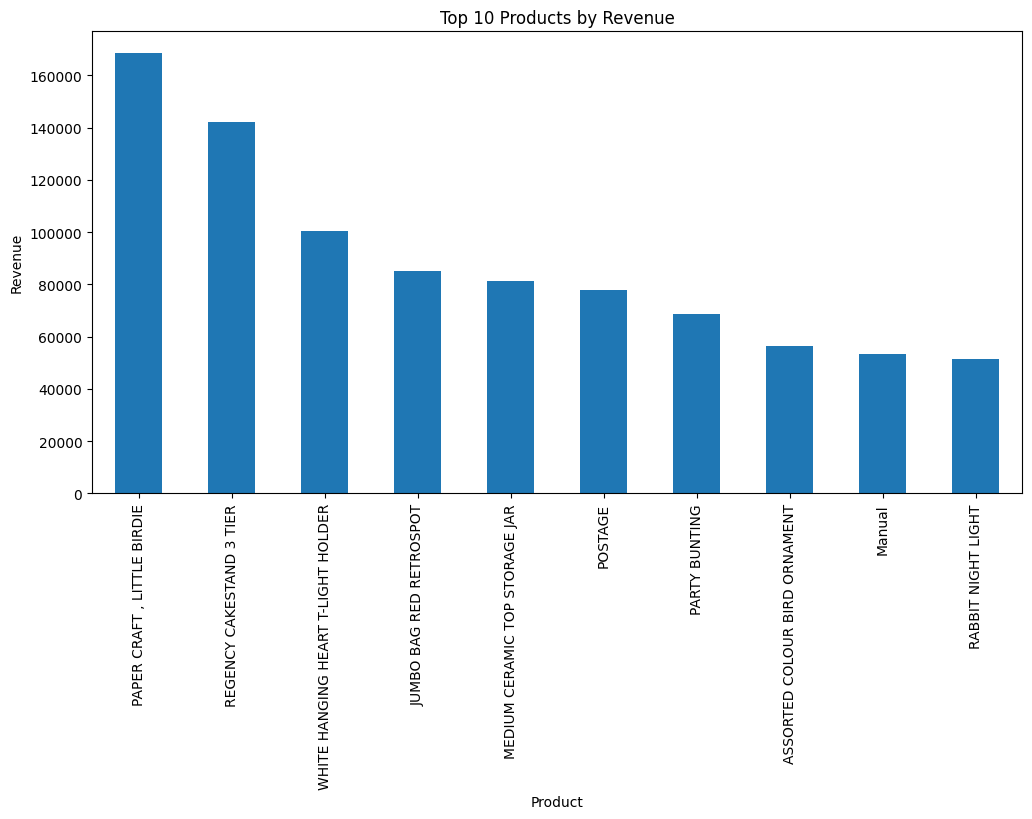

In [22]:
top_products_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
top_products_revenue.head(10).plot(kind='bar')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

### Observation
- PAPER CRAFT.LITTLE BIRDIE contributes the highest revenue.
- High-revenue products may not always be the most frequently sold.
- These products should be prioritized in marketing campaigns.

#Convert InvoiceDate to Datetime

In [23]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   Sales        392692 non-null  float64       
 9   Revenue      392692 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 30.0+ MB


In [25]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

#Monthly Revenue Trend Chart

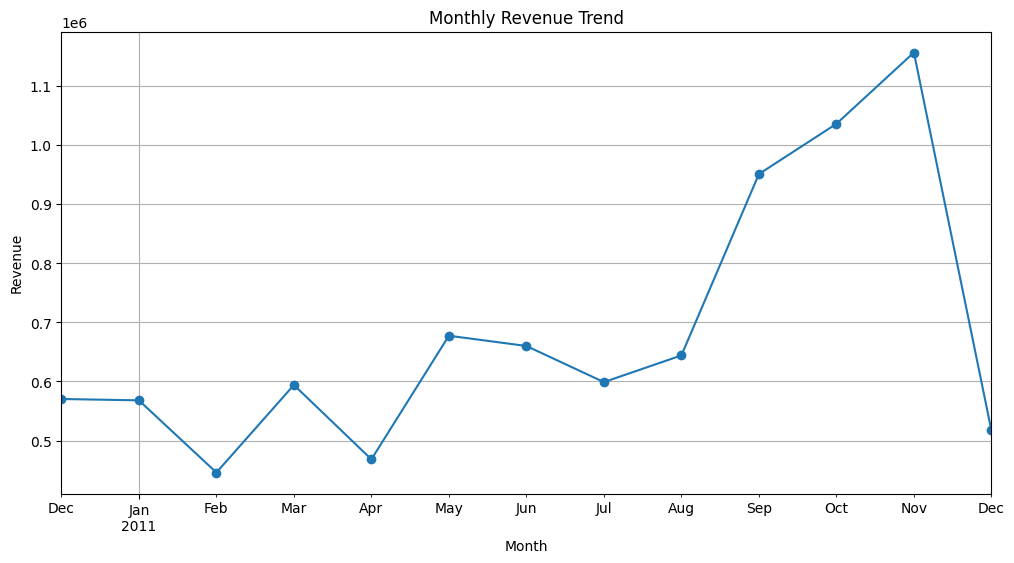

In [26]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()
plt.figure(figsize=(12,6))
monthly_revenue.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

#Top 10 Customers by Revenue

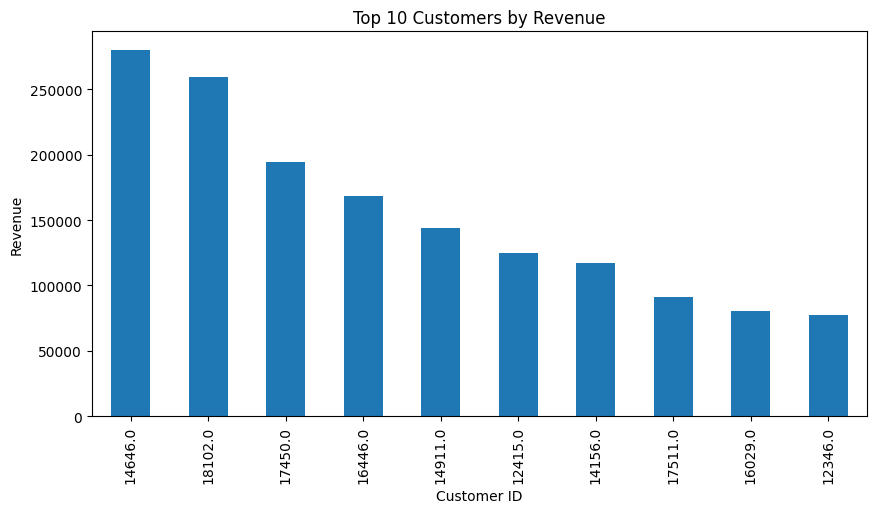

In [27]:
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
customer_revenue.head(10).plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.show()

### Observation
- A small group of customers contributes a significant portion of revenue.
- Retaining these high-value customers is critical for business growth.
- Loyalty programs can help increase customer retention.

# Final EDA Summary

## Key Business Insights

1. The highest number of transactions comes from uNITED KINGDOM.
2. The highest revenue-generating country is UNITED KINGDOM.
3. The most popular product based on quantity sold is PAPER CRAFT.LITTLE BIRDIE.
4. The highest revenue-generating product is PAPER CRAFT.LITTLE BIRDIE.
5. A small number of customers contribute a large share of total revenue.
6. Customer retention strategies should focus on top-spending customers.
7. High-demand products should receive priority in inventory management.